In [35]:
import torch
torch.set_grad_enabled(False)
print("Disabled automatic differentiation")
from transformer_lens import HookedTransformer
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

import transformer_lens.utils as utils
import einops

from joblib import Parallel, delayed
import pandas as pd

from dadapy.data import Data

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
import importlib
import extract_id
importlib.reload(extract_id)
from extract_id import convert_to_distances, compute_ids
import plot_utils
importlib.reload(plot_utils)
from plot_utils import imshow, line, lines
from scipy.stats import linregress

Disabled automatic differentiation


In [2]:
# Load GPT-2 Small
model = HookedTransformer.from_pretrained("gpt2-small", cache_dir = "../../models")

Loaded pretrained model gpt2-small into HookedTransformer


In [28]:
filtered_indices = np.load('../filtered_indices.npy')
# Load prompt from Pile-10K (Prompt 3218)
pile_dataset = load_dataset("NeelNanda/pile-10k")
ds = load_dataset("NeelNanda/pile-10k")['train']
sequences = ds['text']
max_length = 1024

In [29]:
# prompt_number = np.random.choice(filtered_indices)
prompt_number = 3218
tokens = model.to_tokens(sequences[prompt_number], prepend_bos=True)
tokens = tokens[..., :max_length]
logits, cache = model.run_with_cache(tokens)

# Signatures of In Context Learning

In [40]:
tokens = model.to_tokens(sequences[prompt_number], prepend_bos=True)
tokens = tokens[..., :max_length//2]
copied_tokens = torch.concatenate([tokens, tokens], dim = -1)
logits, cache = model.run_with_cache(copied_tokens)

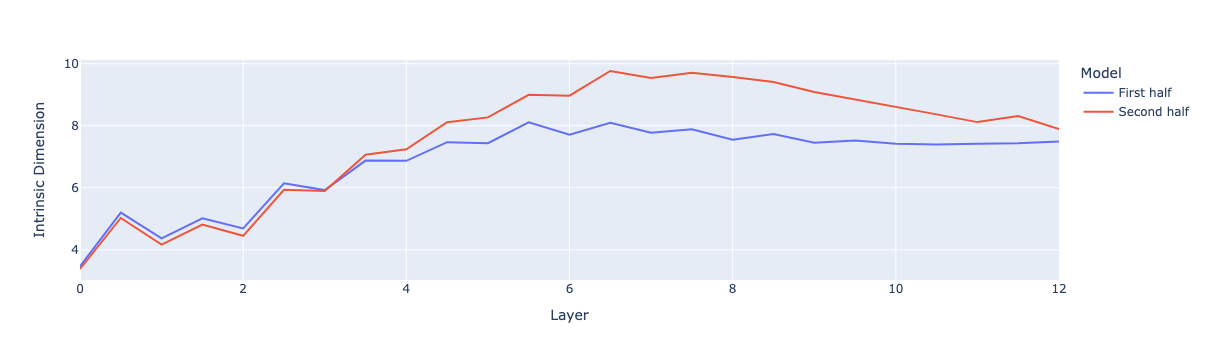

In [41]:
layers = model.cfg.n_layers

# 1. ID from accumulated_resid (pre and mid at each layer)
accumulated_residual, labels = cache.accumulated_resid(layer = -1, incl_mid=True, return_labels = True)
accumulated_residual_distances = convert_to_distances(accumulated_residual.squeeze())
tensors = []

ids = compute_ids(accumulated_residual_distances[:, :max_length//2, :max_length//2].cpu().numpy())
tensors.append(ids[:, 0, 1])

ids = compute_ids(accumulated_residual_distances[:, max_length//2:, max_length//2:].cpu().numpy())
tensors.append(ids[:, 0, 1])
lines(tensors,x=np.arange(model.cfg.n_layers * 2 + 1) / 2, hover_name=labels, names = ["First half", "Second half"])

# What can we learn from $\frac{IDim(V)}{IDim(Z)}$

In [5]:
v_vectors = []
z_vectors = []
num_layers = model.cfg.n_layers

for layer in range(num_layers):
    # The shape is [batch, seq_len, n_heads, head_dim]
    v = cache[f"blocks.{layer}.attn.hook_v"]  # Value vectors
    z = cache[f"blocks.{layer}.attn.hook_z"]  # Head outputs

    v_vectors.append(v)
    z_vectors.append(z)
v_vectors = torch.stack(v_vectors).squeeze().transpose(1,2)
z_vectors = torch.stack(z_vectors).squeeze().transpose(1,2)

In [ ]:
v_distances = utils.to_numpy(torch.cdist(v_vectors, v_vectors))
z_distances = utils.to_numpy(torch.cdist(z_vectors, z_vectors))
v_id = np.array([compute_ids(vd) for vd in v_distances])
z_id = np.array([compute_ids(zd) for zd in z_distances])

In [11]:
attn_matrices = []
num_layers = model.cfg.n_layers
for layer in range(num_layers):
    # shape: [batch, n_heads, seq_len, seq_len]
    attn = cache[f"blocks.{layer}.attn.hook_pattern"]
    attn_matrices.append(attn)
attn_matrices = torch.stack(attn_matrices).squeeze()

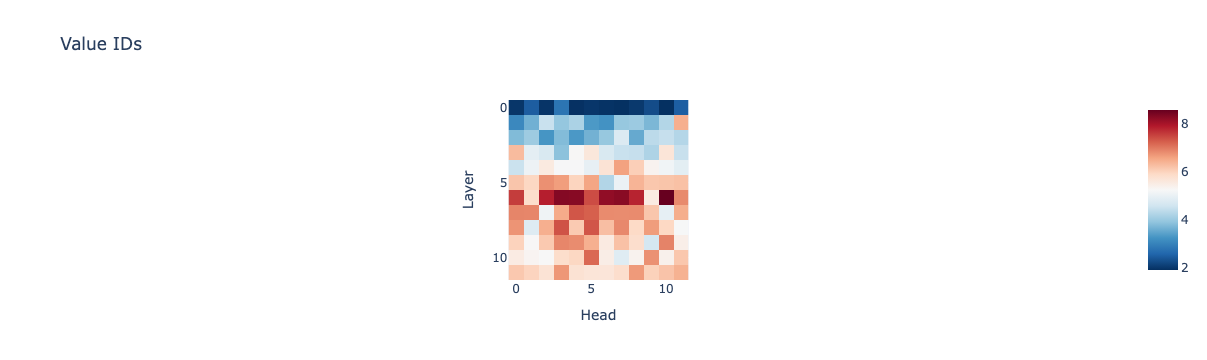

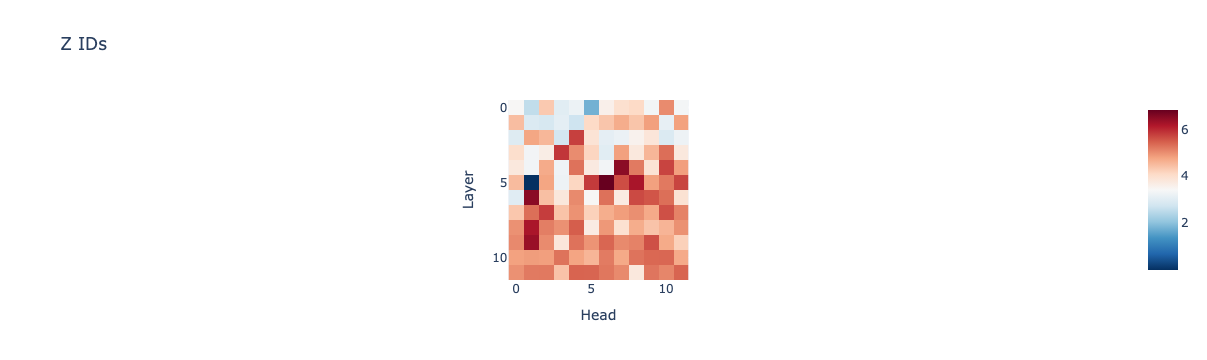

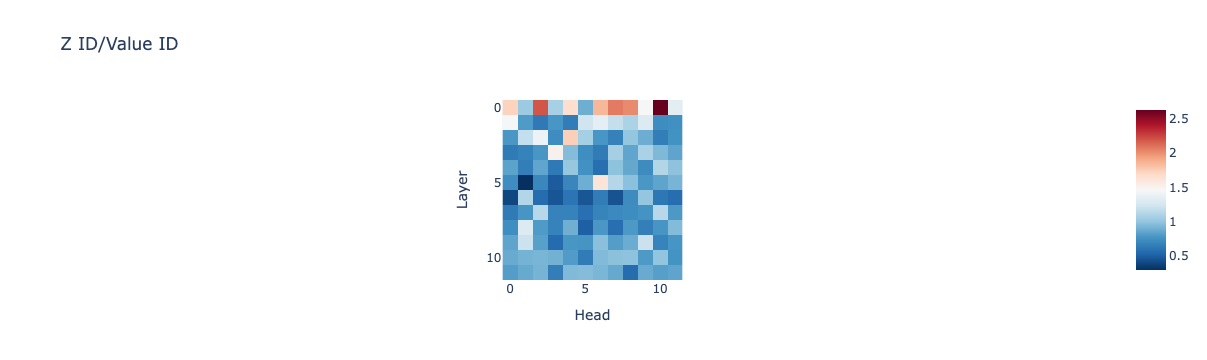

In [12]:
imshow(
      v_id[:, :, 0, 1],
      labels={"x": "Head", "y": "Layer"},
      title="Value IDs",
  )
imshow(
      z_id[:, :, 0, 1],
      labels={"x": "Head", "y": "Layer"},
      title="Z IDs",
  )
imshow(
      z_id[:, :, 0, 1]/v_id[:, :, 0, 1],
      labels={"x": "Head", "y": "Layer"},
      title="Z ID/Value ID",zmin=0.3
  )


### Plotting attention patterns for the first few tokens

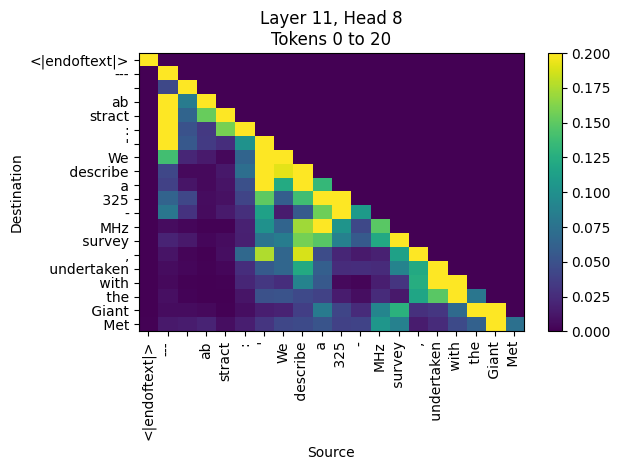

In [13]:
# Choose layer, head to visualize
layer_idx = 11
head_idx = 8
start_window, end_window = 0, 20  # slice of the sequence

# Suppose attn_matrices has shape [num_layers, num_heads, seq_len, seq_len]
attn = attn_matrices[layer_idx, head_idx]   

# Slice out the window [start_window : end_window, start_window : end_window]
attn_window = attn[start_window:end_window, start_window:end_window]

# Convert the corresponding tokens (on batch=0) to strings:
token_strings = model.to_str_tokens(tokens[0, start_window:end_window])

# Plot the attention window
plt.imshow(attn_window.detach().cpu().numpy(), aspect='auto', vmax=0.2)
plt.colorbar()
plt.title(f'Layer {layer_idx}, Head {head_idx}\nTokens {start_window} to {end_window}')
plt.xlabel('Source')
plt.ylabel('Destination')

# Make x-ticks and y-ticks match the size of our window
num_positions = end_window - start_window
plt.xticks(range(num_positions), token_strings, rotation=90)
plt.yticks(range(num_positions), token_strings)

plt.tight_layout()
plt.show()

### Check for local homogeneity for L11H8

In [154]:
hidden_distances = z_distances[11,8]

_, indices = np.unique(hidden_distances, axis = 0, return_index=True)

hidden_distances = hidden_distances[indices, :][:, indices]

sorted_distances = np.sort(hidden_distances, axis = -1)


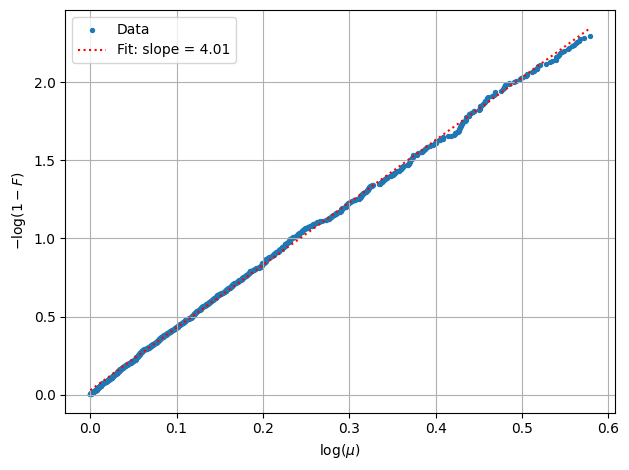

In [156]:

data_fraction = 0.9
# LNUM = 11
N = sorted_distances.shape[-1]
n_eff = int(data_fraction * N)
mu = sorted_distances[:, 2]/sorted_distances[:, 1]
x = np.sort(np.log(mu))[:n_eff]
y = -np.log(1 - np.arange(1, n_eff + 1) / N)  # avoid log(0)

# Fit straight line: y = slope * x + intercept
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Plot scatter + fit
# plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=8, label='Data')
plt.plot(x, slope * x + intercept, color='red', label=f'Fit: slope = {slope:.2f}', linestyle = 'dotted')
plt.xlabel(r'$\log(\mu)$')
plt.ylabel(r'$-\log(1 - F)$')
plt.grid(True)
plt.legend()
# plt.title(f'{model_name.split("/")[-1]}, Layer {LNUM}, prompt {prompt_number}')
plt.tight_layout()
plt.show()

### Now zooming into layer 11, head 8 with many prompts

In [14]:
max_length = 20
num_samples = 5
indices = np.random.choice(len(sequences), num_samples, replace=False)
sampled = [sequences[i] for i in indices]
tokens = model.to_tokens(sampled, prepend_bos=True)
tokens = tokens[..., :max_length]
logits, cache = model.run_with_cache(tokens)

In [20]:
# shape: [batch, n_heads, seq_len, seq_len]
attn_matrix = cache[f"blocks.11.attn.hook_pattern"][:,8]
attn_matrix.shape

torch.Size([5, 20, 20])

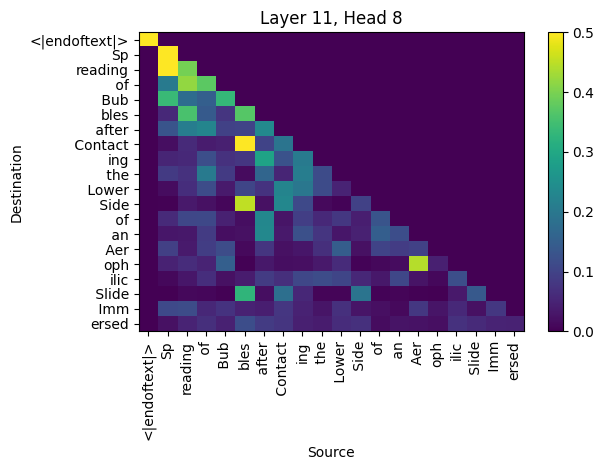

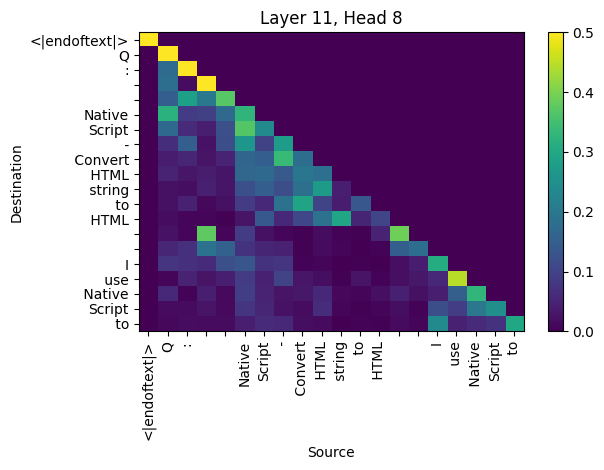

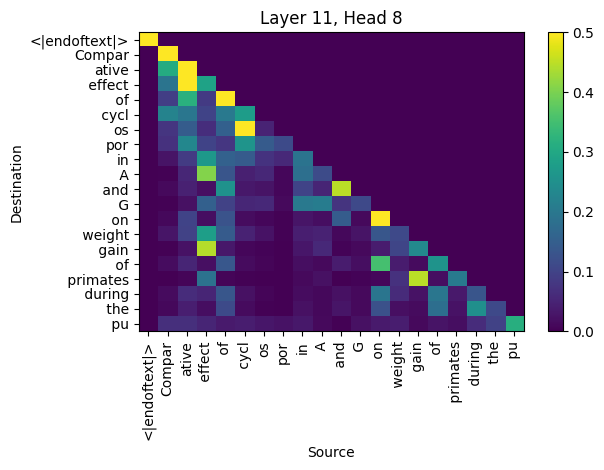

/tmp/ipykernel_34149/4140578446.py:20: UserWarning:

Glyph 9 (	) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 9 (	) missing from font(s) DejaVu Sans.



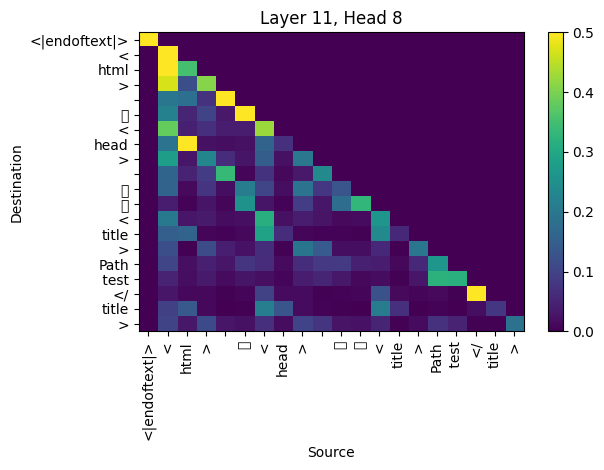

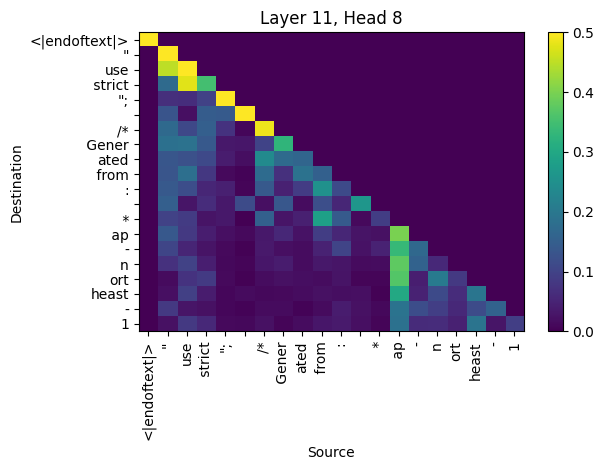

In [21]:
for idx in range(num_samples):
    # Suppose attn_matrices has shape [num_layers, num_heads, seq_len, seq_len]
    attn = attn_matrix[idx]   
    # print(attn.shape)
    # Convert the corresponding tokens (on batch=0) to strings:
    token_strings = model.to_str_tokens(tokens[idx])
    
    # Plot the attention window
    plt.imshow(attn.detach().cpu().numpy(), aspect='auto', vmax=0.5)
    plt.colorbar()
    plt.title(f'Layer 11, Head 8')
    plt.xlabel('Source')
    plt.ylabel('Destination')
    
    # Make x-ticks and y-ticks match the size of our window
    num_positions = tokens.shape[-1] 
    plt.xticks(range(num_positions), token_strings, rotation=90)
    plt.yticks(range(num_positions), token_strings)
    
    plt.tight_layout()
    plt.show()